In [10]:
import polars as pl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [11]:
df = pl.scan_parquet("../data/processed/df_final_for_pipeline.parquet")

# Insight 2: Drivers (Top 10% reach products)
product_reach = df.group_by("product_id").agg(pl.col("user_id").n_unique().alias("reach")).collect()
threshold_driver = product_reach["reach"].quantile(0.9)
driver_ids = product_reach.filter(pl.col("reach") >= threshold_driver)["product_id"].to_list()

# Insight 3: Niche Products (Top 25% fidelity among products with low reach)
product_stats = df.group_by("product_id").agg([
    pl.col("user_id").n_unique().alias("reach"),
    pl.col("reordered").mean().alias("fidelity")
]).collect()
niche_ids = product_stats.filter(
    (pl.col("reach") <= product_stats["reach"].quantile(0.25)) &
    (pl.col("fidelity") >= product_stats["fidelity"].quantile(0.75))
)["product_id"].to_list()

In [12]:
customer_features = df.group_by("user_id").agg([
    # De base
    pl.col("order_id").n_unique().alias("total_orders"),
    pl.col("days_since_prior_order").mean().alias("avg_period"),
    pl.col("reordered").mean().alias("reorder_ratio"),
    pl.col("order_value").sum().alias("total_spend"),
    (pl.col("order_id").count() / pl.col("order_id").n_unique()).alias("avg_basket_size"),

    # INSIGHT 1: Weekend Rush (% of unique departments ordered during weekends)
    (
        pl.col("department_id").filter(pl.col("order_dow").is_in([0, 1])).n_unique() /
        pl.col("department_id").n_unique()
    ).fill_null(1).alias("weekend_big_basket_ratio"),

    # INSIGHT 2: Driver Dependency
    (pl.col("product_id").is_in(driver_ids).sum() / pl.col("product_id").count()).alias("driver_dependency"),

    # INSIGHT 3: Niche Affinity (penetration * fidelity)
    (
        pl.col("product_id").is_in(niche_ids).mean() * pl.col("reordered").filter(pl.col("product_id").is_in(niche_ids)).mean().fill_null(0)
    ).alias("niche_affinity_score"),

    # INSIGHT 5: One-Stop Shop (aisle penetration)
    (pl.col("department_id").n_unique() / 21.0).alias("aisle_penetration"),

    # INSIGHT 6: Healthy & Cheap Affinity
    pl.col("healthy").mean().alias("HAI"),
    pl.col("cheap_product").mean().alias("PSI")
]).with_columns([
    (pl.col("total_orders") / (pl.col("avg_period") + 1)).alias("order_frequency"),
    (pl.col("total_spend") / pl.col("total_orders")).alias("avg_basket_value")
]).collect()

In [13]:
features_list = [
    'order_frequency', 'reorder_ratio', 'avg_basket_size', 'avg_basket_value',
    'weekend_big_basket_ratio', 'driver_dependency', 'niche_affinity_score',
    'aisle_penetration', 'HAI', 'PSI'
]

X = customer_features.select(features_list).to_numpy()
# Log-transform skewed features (avg_basket_value, avg_basket_size) to reduce the impact of outliers
X[:, 3] = np.log1p(X[:, 3])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mbk = MiniBatchKMeans(n_clusters=5, batch_size=4096, random_state=42)
customer_features = customer_features.with_columns(
    pl.Series(name="cluster", values=mbk.fit_predict(X_scaled))
)

Text(0.5, 1.0, 'Méthode du Coude')

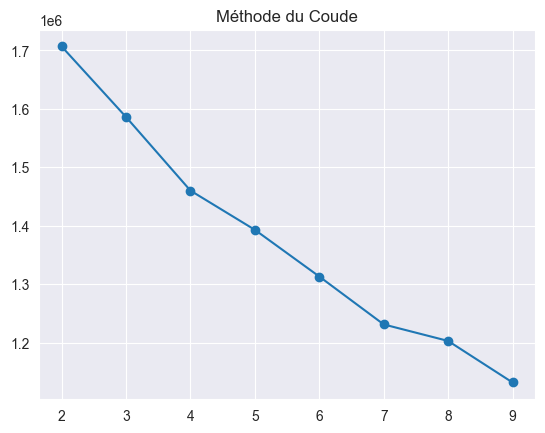

In [14]:
inertias = []
for k in range(2, 10):
    km = MiniBatchKMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.title("Méthode du Coude")

In [15]:
n_clusters = 7

mbk = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=4096,
    random_state=42,
    n_init=10,
    reassignment_ratio=0.1
)
clusters = mbk.fit_predict(X_scaled)
customer_features = customer_features.with_columns(
    pl.Series(name="cluster", values=clusters)
)

In [16]:
centers = mbk.cluster_centers_
# Euclidean distance to cluster centers
dist_to_center = np.sqrt(np.sum((X_scaled - centers[clusters])**2, axis=1))
# We define atypical customers as those in the top 1% of distance to their cluster center
threshold = np.percentile(dist_to_center, 99)
customer_features = customer_features.with_columns(
    pl.Series(name="is_atypical", values=(dist_to_center > threshold))
)

In [17]:
# Never compute silhouette on the whole dataset (13M+ rows) - it's too heavy
idx_sample = np.random.choice(len(X_scaled), 40000, replace=False)
sil_score = silhouette_score(X_scaled[idx_sample], clusters[idx_sample])

print(f"Silhouette score(estimated on 20k pts) : {sil_score:.4f}")
print(f"Number of atypical detected (Top 1%) : {customer_features.filter(pl.col('is_atypical')).shape[0]}")

# --- 6. CLUSTERS SYNTHESE ---
summary = customer_features.group_by("cluster").agg([
    pl.col(f).mean().alias(f"mean_{f}") for f in features_list
]).sort("cluster")

print("\nSummary of clusters :")
print(summary)

# Save results
customer_features.write_parquet("../data/processed/customer_segmentation_results.parquet")

Silhouette score(estimated on 20k pts) : 0.1334
Number of atypical detected (Top 1%) : 2063

Summary of clusters :
shape: (7, 11)
┌─────────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬──────────┬──────────┐
│ cluster ┆ mean_order ┆ mean_reord ┆ mean_avg_b ┆ … ┆ mean_nich ┆ mean_aisl ┆ mean_HAI ┆ mean_PSI │
│ ---     ┆ _frequency ┆ er_ratio   ┆ asket_size ┆   ┆ e_affinit ┆ e_penetra ┆ ---      ┆ ---      │
│ i32     ┆ ---        ┆ ---        ┆ ---        ┆   ┆ y_score   ┆ tion      ┆ f64      ┆ f64      │
│         ┆ f64        ┆ f64        ┆ f64        ┆   ┆ ---       ┆ ---       ┆          ┆          │
│         ┆            ┆            ┆            ┆   ┆ f64       ┆ f64       ┆          ┆          │
╞═════════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪══════════╪══════════╡
│ 0       ┆ 9.2677     ┆ 0.712293   ┆ 9.762068   ┆ … ┆ 0.000832  ┆ 0.687741  ┆ 0.874084 ┆ 0.503973 │
│ 1       ┆ 0.882002   ┆ 0.452869   ┆ 4.119123   ┆ … ┆ 0.00007

C:\Users\natha\AppData\Local\Temp\ipykernel_14200\579987138.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(df))


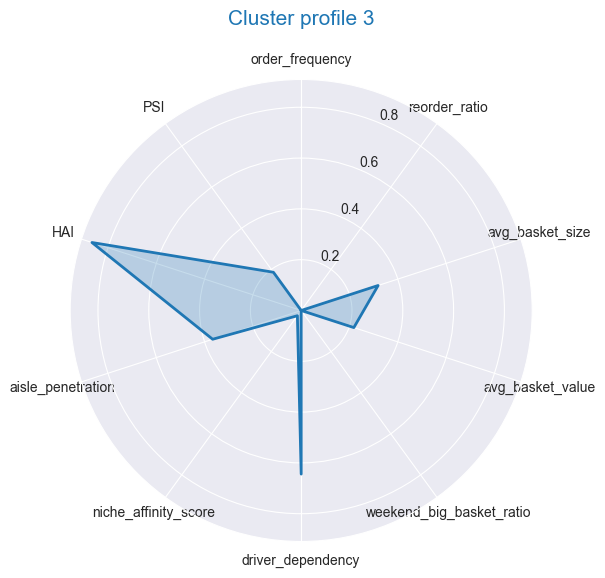

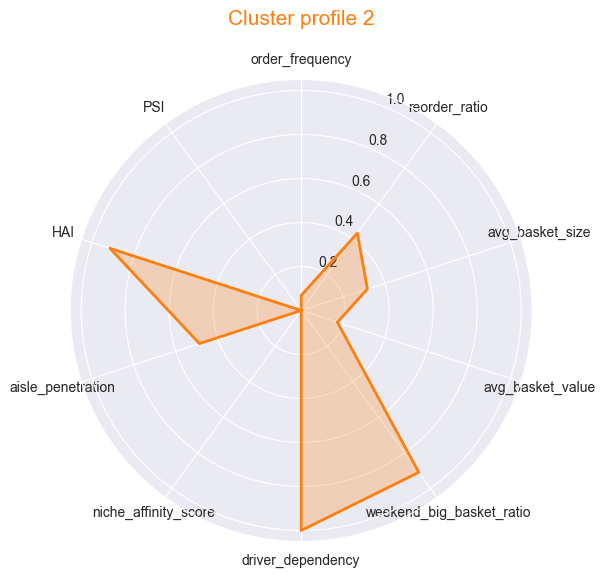

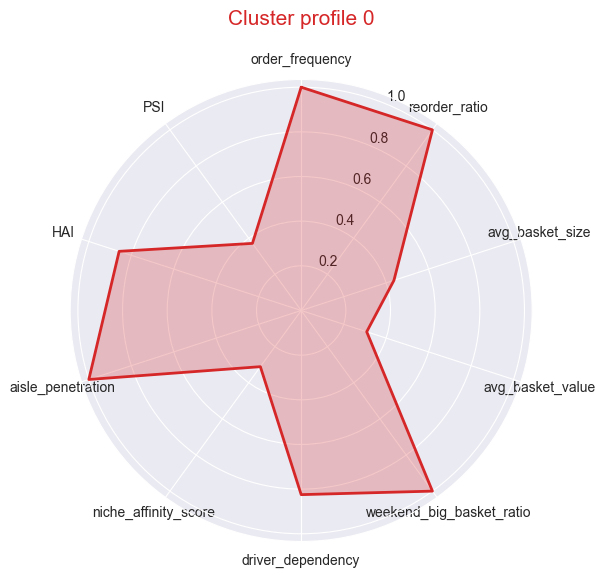

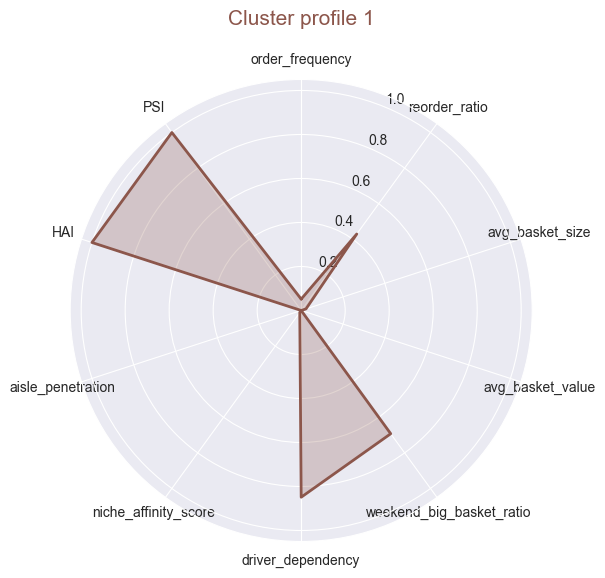

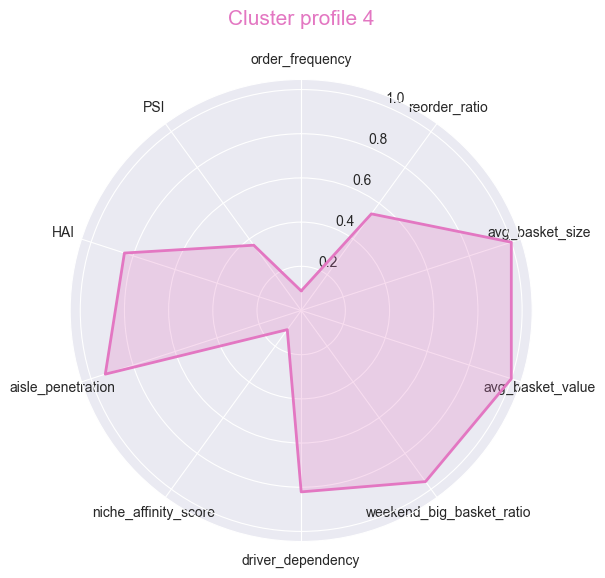

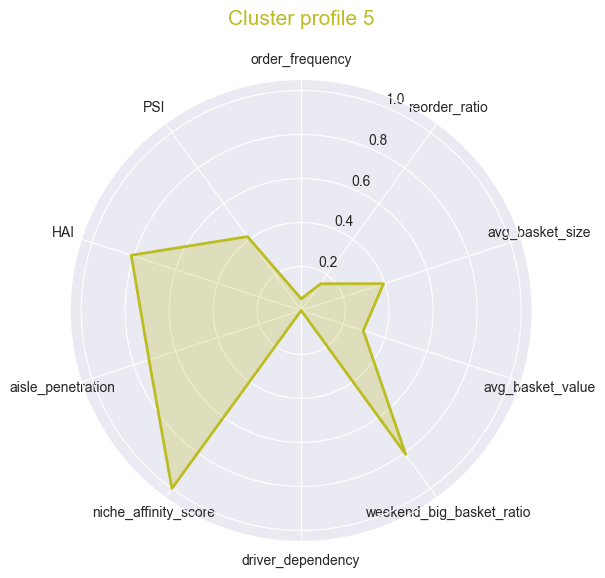

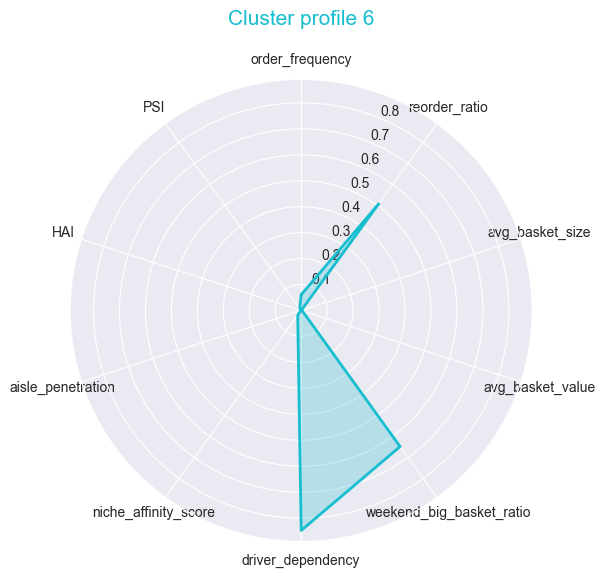

In [18]:
import matplotlib.cm as cm
# 1. Compute mean values for each cluster
summary_df = customer_features.group_by("cluster").agg([
    pl.col(f).mean().alias(f) for f in features_list
]).to_pandas().set_index("cluster")

# 2. Normalize 0-1 in order to display (MinMaxScaler)
# Each axis will have the same size, making the radar chart more interpretable.
scaler_viz = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler_viz.fit_transform(summary_df),
    columns=summary_df.columns,
    index=summary_df.index
)

def make_radar_chart_robust(df):
    labels = df.columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    cmap = cm.get_cmap('tab10', len(df))

    for i in range(len(df)):
        values = df.iloc[i].tolist()
        values += values[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        color = cmap(i)

        ax.fill(angles, values, color=color, alpha=0.25)
        ax.plot(angles, values, color=color, linewidth=2)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels)

        plt.title(f"Cluster profile {df.index[i]}", size=15, color=color, y=1.1)
        plt.show()

make_radar_chart_robust(summary_scaled)